In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
import wrds
db = wrds.Connection(wrds_username = 'xiaoyashi24')

Loading library list...
Done


# Interactive Monthly Stock Performance Analysis Tool

## Introduction
This project develops a small interactive Python-based tool for analysing monthly stock performance.
Users can enter a stock code and a starting month, and the tool retrieves monthly stock data,
cleans and transforms the data, and produces descriptive statistics, visualisations, and
analytical insights.

## Analytical Problem
How can users quickly evaluate the monthly performance and volatility of a selected stock using Python and financial market data?

## Target Users
The target users are business students, finance learners, and beginner investors.

## Data Source
- Source: CSMAR monthly stock trading data
- Table: `csmar.trd_mnth`
- Date accessed: [10 April 2026]

In [11]:
query = f"""
SELECT stkcd, trdmnt, mclsprc, mretwd, mretnd, mnshrtrd, mnvaltrd
FROM csmar.trd_mnth
WHERE stkcd = '{stock_code}'
  AND trdmnt >= {start_month}
"""

df = db.raw_sql(query)

print("Data shape:", df.shape)
df.head()

Data shape: (48, 7)


,stkcd,trdmnt,mclsprc,mretwd,mretnd,mnshrtrd,mnvaltrd
0,000001,202101,23.09,0.193899,0.193899,2792512935.0,58603803798.230003
1,000001,202102,21.38,-0.074058,-0.074058,2243272525.0,52541944392.309998
2,000001,202103,22.01,0.029467,0.029467,2340059951.0,50347476182.970001
3,000001,202104,23.29,0.058155,0.058155,1423476303.0,31264829462.849998
4,000001,202105,24.2,0.047092,0.046801,1015281590.0,24221421505.84


In [9]:
# User inputs
stock_code = '000001'
start_month = 202101

print("Selected stock code:", stock_code)
print("Selected start month:", start_month) 

Selected stock code: 000001
Selected start month: 202101


In [13]:
if df.empty:
    print("No data found. Please check the stock code or start month.")
else:
    print("Data successfully retrieved.")

Data successfully retrieved.


In [16]:
# Keep useful columns
df = df[['stkcd', 'trdmnt', 'mclsprc', 'mretwd', 'mretnd', 'mnshrtrd', 'mnvaltrd']].copy()

# Remove rows with key missing values
df = df.dropna(subset=['trdmnt', 'mretwd', 'mclsprc'])

# Convert trdmnt to datetime
df['trdmnt'] = pd.to_datetime(df['trdmnt'], errors='coerce')

# Drop rows where date conversion failed
df = df.dropna(subset=['trdmnt'])

# Sort by date
df = df.sort_values('trdmnt').reset_index(drop=True)

print("Cleaned data shape:", df.shape)
df.head()

Cleaned data shape: (48, 7)


,stkcd,trdmnt,mclsprc,mretwd,mretnd,mnshrtrd,mnvaltrd
0,000001,2021-01-01,23.09,0.193899,0.193899,2792512935.0,58603803798.230003
1,000001,2021-02-01,21.38,-0.074058,-0.074058,2243272525.0,52541944392.309998
2,000001,2021-03-01,22.01,0.029467,0.029467,2340059951.0,50347476182.970001
3,000001,2021-04-01,23.29,0.058155,0.058155,1423476303.0,31264829462.849998
4,000001,2021-05-01,24.2,0.047092,0.046801,1015281590.0,24221421505.84


In [17]:
# Create year-month label
df['year_month'] = df['trdmnt'].dt.strftime('%Y-%m')

# Calculate cumulative return
df['cum_return'] = (1 + df['mretwd']).cumprod() - 1

# Calculate monthly price change
df['price_change'] = df['mclsprc'].diff()

df.head()

,stkcd,trdmnt,mclsprc,mretwd,mretnd,mnshrtrd,mnvaltrd,year_month,cum_return,price_change
0,000001,2021-01-01,23.09,0.193899,0.193899,2792512935.0,58603803798.230003,2021-01,0.193899,<NA>
1,000001,2021-02-01,21.38,-0.074058,-0.074058,2243272525.0,52541944392.309998,2021-02,0.105481,-1.71
2,000001,2021-03-01,22.01,0.029467,0.029467,2340059951.0,50347476182.970001,2021-03,0.138056,0.63
3,000001,2021-04-01,23.29,0.058155,0.058155,1423476303.0,31264829462.849998,2021-04,0.20424,1.28
4,000001,2021-05-01,24.2,0.047092,0.046801,1015281590.0,24221421505.84,2021-05,0.26095,0.91


In [18]:
print("Summary statistics for monthly return (mretwd):")
print(df['mretwd'].describe())

print("\nSummary statistics for monthly closing price (mclsprc):")
print(df['mclsprc'].describe())

Summary statistics for monthly return (mretwd):
count        48.0
mean    -0.003773
std      0.088961
min     -0.217949
25%     -0.067396
50%     -0.004478
75%      0.028457
max      0.260155
Name: mretwd, dtype: Float64

Summary statistics for monthly closing price (mclsprc):
count         48.0
mean     14.150625
std       4.149812
min           9.39
25%         11.125
50%         12.615
75%        15.9925
max           24.2
Name: mclsprc, dtype: Float64


In [19]:
mean_return = df['mretwd'].mean()
std_return = df['mretwd'].std()
max_return = df['mretwd'].max()
min_return = df['mretwd'].min()

mean_price = df['mclsprc'].mean()
std_price = df['mclsprc'].std()
max_price = df['mclsprc'].max()
min_price = df['mclsprc'].min()

best_month = df.loc[df['mretwd'].idxmax()]
worst_month = df.loc[df['mretwd'].idxmin()]

print("Average monthly return:", round(mean_return, 4))
print("Return volatility (std):", round(std_return, 4))
print("Highest monthly return:", round(max_return, 4))
print("Lowest monthly return:", round(min_return, 4))

print("\nAverage monthly closing price:", round(mean_price, 2))
print("Price volatility (std):", round(std_price, 2))
print("Highest monthly closing price:", round(max_price, 2))
print("Lowest monthly closing price:", round(min_price, 2))

print("\nBest month:")
print(best_month)

print("\nWorst month:")
print(worst_month)

Average monthly return: -0.0038
Return volatility (std): 0.089
Highest monthly return: 0.2602
Lowest monthly return: -0.2179

Average monthly closing price: 14.15
Price volatility (std): 4.15
Highest monthly closing price: 24.2
Lowest monthly closing price: 9.39

Best month:
stkcd                        000001
trdmnt          2022-11-01 00:00:00
mclsprc                       13.03
mretwd                     0.260155
mretnd                     0.260155
mnshrtrd               3526282382.0
mnvaltrd         41486699201.529999
year_month                  2022-11
cum_return                -0.308983
price_change                   2.69
Name: 22, dtype: object

Worst month:
stkcd                        000001
trdmnt          2021-07-01 00:00:00
mclsprc                       17.69
mretwd                    -0.217949
mretnd                    -0.217949
mnshrtrd               1935733252.0
mnvaltrd         39543208925.129997
year_month                  2021-07
cum_return                -0.078256
pr

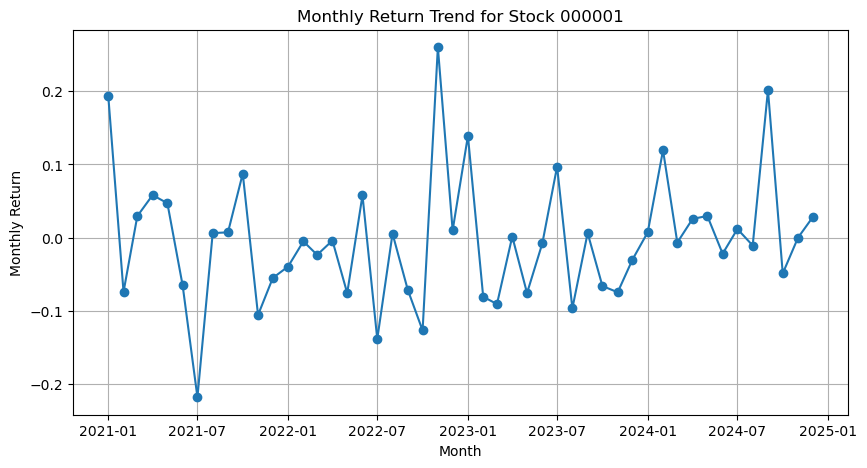

In [20]:
plt.figure(figsize=(10,5))
plt.plot(df['trdmnt'], df['mretwd'], marker='o')
plt.title(f'Monthly Return Trend for Stock {stock_code}')
plt.xlabel('Month')
plt.ylabel('Monthly Return')
plt.grid(True)
plt.show()

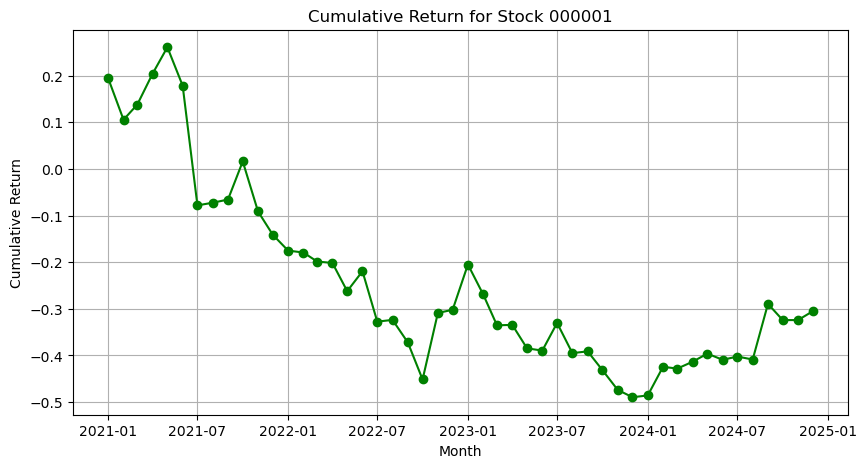

In [21]:
plt.figure(figsize=(10,5))
plt.plot(df['trdmnt'], df['cum_return'], marker='o', color='green')
plt.title(f'Cumulative Return for Stock {stock_code}')
plt.xlabel('Month')
plt.ylabel('Cumulative Return')
plt.grid(True)
plt.show()

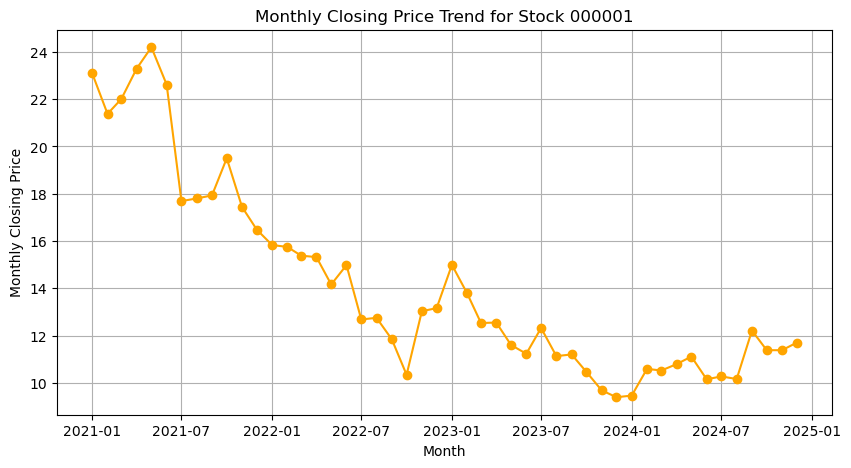

In [22]:
plt.figure(figsize=(10,5))
plt.plot(df['trdmnt'], df['mclsprc'], marker='o', color='orange')
plt.title(f'Monthly Closing Price Trend for Stock {stock_code}')
plt.xlabel('Month')
plt.ylabel('Monthly Closing Price')
plt.grid(True)
plt.show()

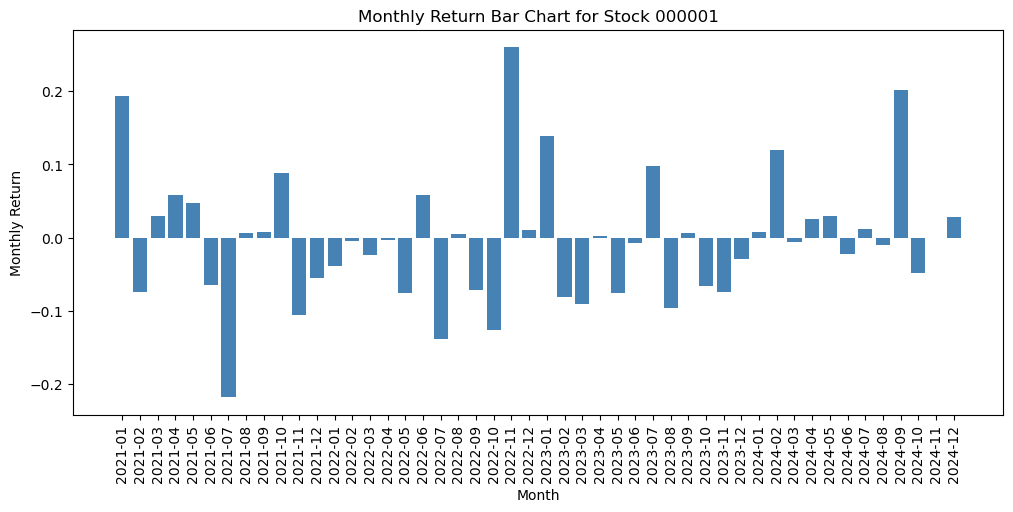

In [23]:
plt.figure(figsize=(12,5))
plt.bar(df['year_month'], df['mretwd'], color='steelblue')
plt.title(f'Monthly Return Bar Chart for Stock {stock_code}')
plt.xlabel('Month')
plt.ylabel('Monthly Return')
plt.xticks(rotation=90)
plt.show()

In [24]:
print("Analytical Insight")

if mean_return > 0:
    print(f"- Stock {stock_code} delivered a positive average monthly return over the selected period.")
else:
    print(f"- Stock {stock_code} delivered a negative average monthly return over the selected period.")

if std_return > 0.1:
    print("- The stock shows relatively high volatility in monthly returns.")
else:
    print("- The stock shows relatively moderate monthly return volatility.")

print(f"- The best-performing month was {best_month['trdmnt'].strftime('%Y-%m')}, with a return of {best_month['mretwd']:.4f}.")
print(f"- The worst-performing month was {worst_month['trdmnt'].strftime('%Y-%m')}, with a return of {worst_month['mretwd']:.4f}.")

if df['cum_return'].iloc[-1] > 0:
    print("- Overall cumulative return is positive over the selected period.")
else:
    print("- Overall cumulative return is negative over the selected period.")

if df['mclsprc'].iloc[-1] > df['mclsprc'].iloc[0]:
    print("- The monthly closing price shows an overall upward trend.")
else:
    print("- The monthly closing price does not show a clear upward trend.")

Analytical Insight
- Stock 000001 delivered a negative average monthly return over the selected period.
- The stock shows relatively moderate monthly return volatility.
- The best-performing month was 2022-11, with a return of 0.2602.
- The worst-performing month was 2021-07, with a return of -0.2179.
- Overall cumulative return is negative over the selected period.
- The monthly closing price does not show a clear upward trend.


In [26]:
import os

output_file = f"{stock_code}_monthly_stock_analysis.xlsx"
df.to_excel(output_file, index=False)

print("File saved as:", output_file)
print("Saved in folder:", os.getcwd())

File saved as: 000001_monthly_stock_analysis.xlsx
Saved in folder: /Users/shixiaoya


## Methods Used

This project applies the following Python-based analytical steps:

1. **Data acquisition**  
   Monthly stock data were retrieved from the CSMAR `trd_mnth` table.

2. **Data cleaning**  
   Missing values were removed and only relevant variables were kept.

3. **Data transformation**  
   The month variable was converted to datetime format, cumulative return was calculated,
   and monthly price changes were derived.

4. **Descriptive analysis**  
   Key statistics such as average return, volatility, best month, and worst month were calculated.

5. **Visualisation**  
   Line charts and bar charts were used to present stock performance patterns clearly.

## Conclusion

This project developed a small interactive Python-based stock analysis tool using a business-related dataset from CSMAR.
The tool allows users to input a stock code and a starting month to retrieve monthly stock data and perform
data cleaning, transformation, descriptive analysis, and visualisation.

The final output communicates analytical value by helping users understand stock return behaviour, price trends,
and volatility over time. This makes the tool suitable for business students, finance learners, and beginner investors.